## Laboratorio #1 - Modelamiento y Simulación
Primero, definimos una clase que defina la estructura en que se abirdaran los ejercicios, usando los métodos de: **Initialize, Observe y Update**.

In [2]:
from abc import ABC

class Base(ABC):
  ''''
  Base class for all complex systems simulations.
  
  methods:
    initialize: initializes the simulation
    visualize: visualizes the simulation
    update: updates the simulation
  '''
  
  def initialize(self):
    raise NotImplementedError("initialize method is not implemented")
  
  def observe(self):
    raise NotImplementedError("visualize method is not implemented")

  def update(self):
    raise NotImplementedError("update method is not implemented")

Hacemos los `imports` necesarios para la ejecución del código, y creamos la carpeta donde se guardaran los graficos resultantes.

In [ ]:
# Define necessary imports
from matplotlib import pyplot as plt
import numpy as np
import os

if not os.path.exists("./lab1_plots"):
  os.makedirs("./lab1_plots")

### Ejercicio 1
Para el sistema $x_{t} = ax_{t-1}$. Realiza simulaciones para varios valores del
parámetro 𝒂 para observar qué tipos de comportamientos son posibles
en este modelo y cómo el valor de 𝒂 determina el comportamiento
resultante.

In [ ]:
class Ex1(Base):
  def __init__(self, initial_value=1, constant=1, iters=10):
    super().__init__()
    self.initial_value = initial_value
    self.constant = constant
    self.current = self.initial_value
    self.result = []

    self.initialize()
    for _ in range(iters):
      self.update()
      self.observe()

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Ejercicio 1")
    plt.grid(True)
    plt.show()
    plt.savefig("./lab1_plots/ex1.png")

  def initialize(self):
    self.result.append(self.current)

  def observe(self):
    plt.plot(np.log10(self.result)) # Logarithmic scale

  def update(self):
    self.current *= self.constant
    self.result.append(self.current)

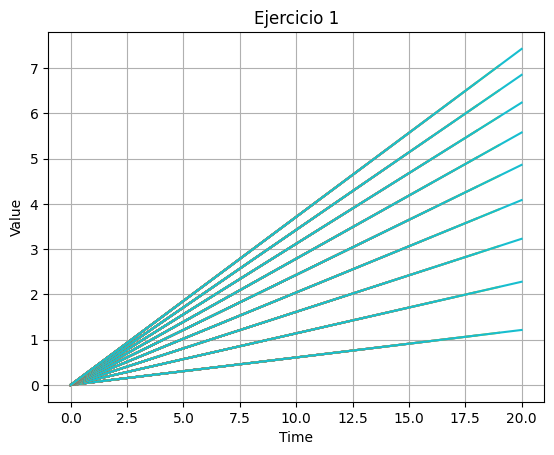

In [36]:
# Run the simulation with different constants
constants = [1 + (0.15 * i) for i in range(1, 10)]
for constant in constants:
  ex1 = Ex1(constant=constant, iters=20)

### Ejercicio 2
Para los siguientes sistemas realice una simulación computacional:

1. $x_t = ax_{t-1} + b$
2. $x_t = ax_{t-1} + bx_{t-2} + cx_{t-3}$
3. $x_t = ax_{t-1}(1 - x_{t-1})$
4. $x_t = ax_{t-1} + bx_{t-2} + c\sqrt{x_{t-1}x_{t-3}}$

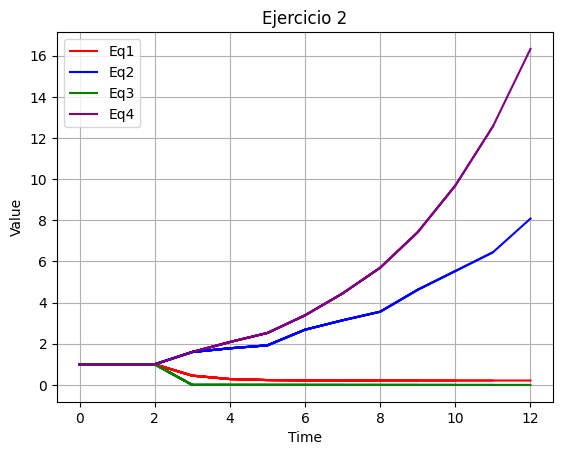

In [80]:
from math import sqrt

class Ex2(Base):

  def __init__(self, initial_values=[1, 2, 3], constants=[1, 2, 3], iters=10):
    super().__init__()
    self.initial_values = initial_values
    self.constants = constants
    self.currents = []
    self.results = []

    self.initialize()
    for _ in range(iters):
      self.update()
      self.observe()

    plt.legend(["Eq1", "Eq2", "Eq3", "Eq4"])
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Ejercicio 2")
    plt.grid(True)
    plt.savefig("./lab1_plots/ex2.png")

  def initialize(self):
    self.results = [[v for v in self.initial_values] for _ in range(4)]
    self.currents = [self.initial_values[-1]] * 4

  def observe(self):
    for idx, res in enumerate(self.results):
      self.results[idx].append(self.currents[idx])
    
    plt.plot(self.results[0], color="red")
    plt.plot(self.results[1], color="blue")
    plt.plot(self.results[2], color="green")
    plt.plot(self.results[3], color="purple")

  def update(self):
    a, b, c = self.constants

    eqs = {
      0: lambda t1: (a * t1) + b,
      1: lambda t1, t2, t3: (a * t1) + (b * t2) + (c * t3),
      2: lambda t1: a * t1 * (1 - t1),
      3: lambda t1, t2, t3: (a * t1) + (b * t2) + c * sqrt(t1 * t3),
    }

    for idx, res in enumerate(self.results):
      t3, t2, t1 = res[-3:]
      if idx in [0, 2]:
        self.currents[idx] = eqs[idx](t1)
      else:
        self.currents[idx] = eqs[idx](t1, t2, t3)

# Example usage
ex2 = Ex2(initial_values=[1, 1, 1], constants=[0.3, 0.15, 1.15])


### Ejercicio 3
Para el siguiente sistema de dos variables de estado, realice
simulaciones de la evolución del sistema y represente el espacio de fase
para diferentes valores de 𝑎, 𝑏, 𝑐 y 𝑑. 

$$ x_t = ax_{t-1} + by_{t-1} $$
$$ y_t = cx_{t-1} + dy_{t-1} $$

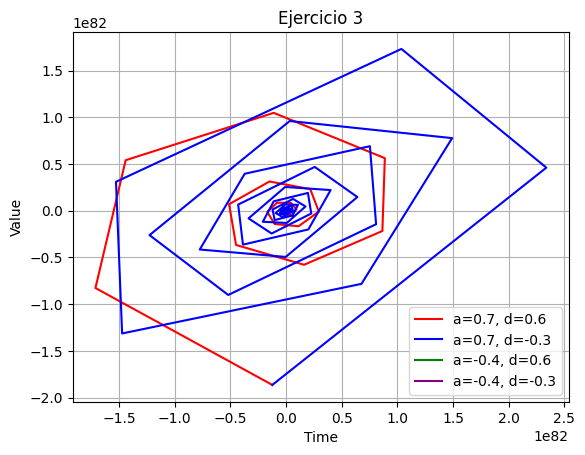

In [162]:
class Ex3(Base):
  
  def __init__(self, 
               initial_values=[1, 1], 
               constants=[[0.7, -0.4], -1.3, 0.8, [0.6, -0.3]], 
               iters=1000
              ):
    super().__init__()
    self.initial_values = initial_values
    self.constants = constants
    self.currents = initial_values
    self.results = []
    
    va, b, c, vd = self.constants
    colors = ["red", "blue", "green", "purple"]
    i = 0
  
    for a in va:
      for d in vd:
        self.initialize()
        self.constants = [a, b, c, d]
        color = colors[i]
        i += 1
        for _ in range(iters):
          self.update()
          self.observe()
        plt.plot(self.results[0], self.results[1], label=f"a={a}, d={d}", color=color)
    
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Ejercicio 3")
    plt.legend()
    plt.grid(True)
    plt.savefig("./lab1_plots/ex3.png")
    
  def initialize(self):
    self.results = []
    self.currents = self.initial_values
    self.results.append([self.currents[0]])
    self.results.append([self.currents[1]])
    
  def observe(self):
    self.results[0].append(self.currents[0])
    self.results[1].append(self.currents[1])
    
  def update(self):
    a, b, c, d = self.constants
    x_p, y_p = self.currents
    
    self.currents[0] = a * x_p + b * y_p
    self.currents[1] = c * x_p + d * y_p
    
# Example usage
ex3 = Ex3(initial_values=[1, 1])

### Ejercicio 4
Simula el comportamiento de la siguiente secuencia de Fibonacci.
Primero, necesitas convertirla en una ecuación en diferencias de primer
orden con dos variables y luego implementar un código de simulación
para ella.

$$ x_t = x_{t-1} + x_{t-2} \\ x_1 = 1 \\ x_2 = 2 $$

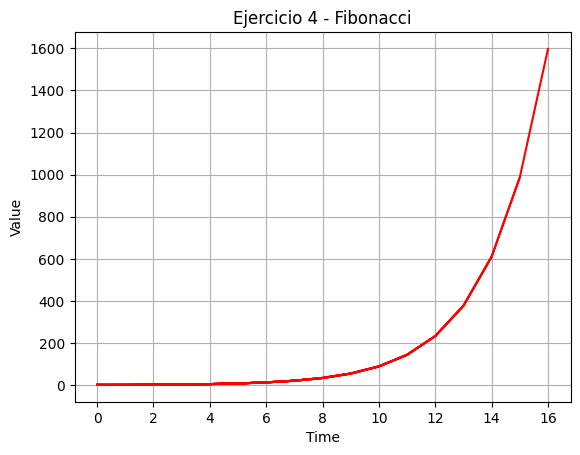

In [166]:
class FiboService(Base):

  def __init__(self):
    super().__init__()
    self.result = []
    self.current = 1

    self.initialize()
    for _ in range(15):
      self.update()
      self.visualize()

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title("Ejercicio 4 - Fibonacci")
    plt.grid()
    plt.show()

  def initialize(self):
    self.result = [self.current] * 2

  def visualize(self):
    self.result.append(self.current)
    plt.plot(self.result, color="red")

  def update(self):
    self.current = sum(self.result[-2:])

fibo_service = FiboService()